In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class SimpleLinearRegression:
    def __init__(self):
        self.coefficient_ = None
        self.intercept_ = None
        self.r2score_ = None

    def fit(self, X, y):
        n = len(X)
        X_b = np.c_[np.ones((n,1)), X]

        self.coefficients_ = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
        self.intercept_ = self.coefficients_[0]
        y_pred = X_b.dot(self.coefficients_)
        # R²
        self.r2score_ = 1 - (np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2))
        self.y_pred_ = y_pred

    def predict(self, X):
        X_b = np.c_[np.ones((len(X),1)), X]
        return X_b.dot(self.coefficients_)

Intercepto (b0): -0.3631
Coeficiente (b1): 0.4158
R² Score: 0.9271


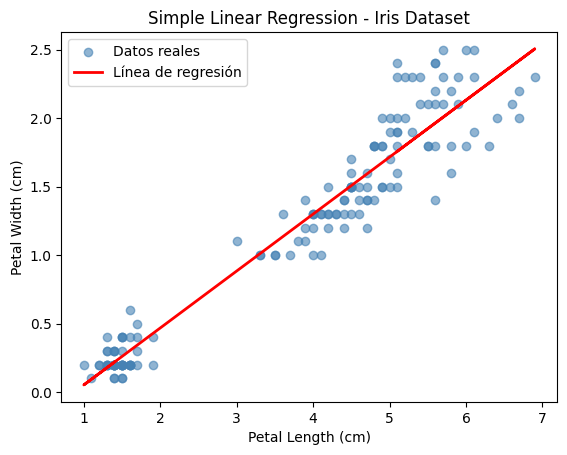

In [3]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Cargar datos
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
X = df[['petal length (cm)']]
y = df['petal width (cm)']

# 2. Ajustar modelo
model = LinearRegression()
model.fit(X, y)

# 3. Coeficientes y R²
print(f"Intercepto (b0): {model.intercept_:.4f}")
print(f"Coeficiente (b1): {model.coef_[0]:.4f}")
print(f"R² Score: {model.score(X, y):.4f}")

# 4. Graficar
plt.scatter(X, y, color='steelblue', alpha=0.6, label='Datos reales')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Línea de regresión')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Simple Linear Regression - Iris Dataset')
plt.legend()
plt.show()